
# OFZ vs Bank Deposit on 23 April 2026  
## One-year comparison for a RUB 12,000,000 investor

This notebook compares two alternatives available to a Russian retail investor on **23 April 2026** over a **1-year horizon**:

1. **A bank deposit**
2. **An investment in OFZs (Russian federal government bonds)**

The comparison is made **after taxes and commissions**, which is essential because:

- deposit income may be partially taxable;
- bond income is generally subject to personal income tax;
- buying and selling bonds through a broker involves commissions.

The notebook is written in a transparent way and is designed for adaptation: you can change the budget, tax assumptions, deposit rate, commissions, or the OFZ issue.



## Methodological note

There are two slightly different tasks here:

### 1. A strict one-year market comparison
For this, the most natural benchmark is the **1-year CBR zero-coupon yield curve point**, because it reflects the market-implied government yield for a 1-year horizon.

### 2. A comparison using a real parsable OFZ issue
For this, we additionally parse **one actual OFZ page from MOEX**. This gives us a concrete bond example with real market fields such as:

- yield,
- maturity date,
- coupon amount,
- coupon date.

This notebook therefore combines both approaches:

- **CBR zero-coupon curve** for the clean 1-year comparison,
- **MOEX issue page** for a real bond example.

> Important limitation: a specific OFZ issue rarely matches the horizon perfectly.  
> For a strict 1-year investment decision, the curve-based 1-year yield is usually a better benchmark than any one arbitrary bond.



## Data sources used in the code

The code below is set up to parse these public pages:

- **CBR zero-coupon yield curve page**  
  <https://www.cbr.ru/hd_base/zcyc_params/zcyc/>

- **MOEX issue page for OFZ 26219**  
  <https://www.moex.com/en/issue.aspx?board=tqob&code=su26219rmfs4>

The notebook assumes that, as of the analysis date:

- the **deposit reference rate** for maturities from **181 days to 1 year** is **12.68%**;
- the **1-year CBR zero-coupon curve point** is around **12.90%**;
- a parsable example bond is **OFZ 26219**.

If the public pages update later, the parsed values may change.


In [27]:

import math
import re
import requests
import pandas as pd
from bs4 import BeautifulSoup
from datetime import datetime
import matplotlib.pyplot as plt


## Step 1. Set the main assumptions

We assume:

- **Budget:** RUB 12,000,000
- **Deposit rate:** 12.68%
- **Broker commission:** 0.05% to buy and 0.05% to sell
- **Personal income tax rate:** 13%

For the **deposit tax threshold**, we keep an explicit scenario parameter.

This is important because for a deposit opened on **23 April 2026** and maturing around **23 April 2027**, the exact tax treatment depends on the relevant tax-year rule application.  
So instead of pretending the threshold is fully known in advance, we make it adjustable.


In [2]:

# ============================================================
# Main assumptions
# ============================================================

BUDGET = 12_000_000

CBR_ZCYC_URL = "https://www.cbr.ru/hd_base/zcyc_params/zcyc/"
MOEX_ISSUE_URL = "https://www.moex.com/en/issue.aspx?board=tqob&code=su26219rmfs4"

# Average maximum retail deposit rate for 181 days to 1 year
DEPOSIT_RATE = 0.1268  # 12.68%
#https://www.cbr.ru/press/pr/?file=639123797974313260BANK_SECTOR.htm

# Example brokerage commissions
BROKER_BUY_FEE = 0.0005   # 0.05%
BROKER_SELL_FEE = 0.0005  # 0.05%

# Russian personal income tax rate for a resident
NDFL_RATE = 0.13

# Base-case scenario for deposit tax-free threshold
DEPOSIT_TAX_FREE_THRESHOLD = 150_000



## Step 2. Build parsers

The next cell defines two helper functions:

### `parse_cbr_zcyc`
This function parses the **CBR zero-coupon yield curve page** and extracts:

- the page date,
- the full maturity grid,
- the full yield grid,
- the **1-year point**.

### `parse_moex_issue`
This function parses a **specific MOEX OFZ page** and extracts:

- instrument name,
- yield,
- maturity date,
- coupon amount,
- coupon date.

These are intentionally simple parsers based on page text, which makes them easy to read and modify.


In [13]:
import re
from datetime import datetime

def _extract_floats(text: str) -> list[float]:
    """
    Extract numeric values from text in a robust way.
    Supports both dot and comma decimals.
    """
    matches = re.findall(r"-?\d+(?:[.,]\d+)?", text)
    return [float(x.replace(",", ".")) for x in matches]


In [16]:
import re
import requests
from bs4 import BeautifulSoup
from datetime import datetime

def parse_cbr_zcyc(url: str) -> dict:
    """
    Robust parser for the CBR zero-coupon yield curve page.

    It works even if the page splits:
    - the heading line
    - and the numeric cells
    into separate text lines.
    """
    headers = {
        "User-Agent": "Mozilla/5.0",
        "Accept-Language": "ru-RU,ru;q=0.9,en;q=0.8",
    }

    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")
    text = soup.get_text("\n", strip=True).replace("\xa0", " ")

    lines = [re.sub(r"\s+", " ", line).strip() for line in text.splitlines()]
    lines = [line for line in lines if line]

    result = {
        "page_date": None,
        "maturities_years": [],
        "yields_pct": [],
        "yield_1y_pct": None,
        "matched_maturity_years": None
    }

    # ----------------------------
    # 1) Parse page date
    # ----------------------------
    for line in lines:
        m = re.search(r"\b(\d{2}\.\d{2}\.\d{4})\b", line)
        if m:
            result["page_date"] = datetime.strptime(
                m.group(1), "%d.%m.%Y"
            ).date().isoformat()
            break

    # ----------------------------
    # 2) Find heading positions
    # ----------------------------
    maturity_idx = next(
        (i for i, line in enumerate(lines) if "Срок до погашения" in line),
        None
    )
    yield_idx = next(
        (i for i, line in enumerate(lines) if "Доходность" in line and "% годовых" in line),
        None
    )

    if maturity_idx is None:
        raise ValueError(f"Could not find maturity heading. First 40 lines: {lines[:40]}")
    if yield_idx is None:
        raise ValueError(f"Could not find yield heading. First 40 lines: {lines[:40]}")

    # ----------------------------
    # 3) Collect numeric values AFTER the heading
    # ----------------------------
    def collect_numbers_after(start_idx: int, stop_idx: int | None = None, max_count: int = 12):
        nums = []
        end = stop_idx if stop_idx is not None else len(lines)

        for j in range(start_idx + 1, end):
            found = re.findall(r"\d+(?:[.,]\d+)?", lines[j])
            for x in found:
                nums.append(float(x.replace(",", ".")))
                if len(nums) >= max_count:
                    return nums
        return nums

    maturities = collect_numbers_after(maturity_idx, stop_idx=yield_idx, max_count=12)
    yields_pct = collect_numbers_after(yield_idx, stop_idx=None, max_count=12)

    # Fallback: sometimes the numbers are in the same line as the heading
    if not maturities:
        maturities = [
            float(x.replace(",", "."))
            for x in re.findall(r"\d+(?:[.,]\d+)?", lines[maturity_idx])
        ]
    if not yields_pct:
        yields_pct = [
            float(x.replace(",", "."))
            for x in re.findall(r"\d+(?:[.,]\d+)?", lines[yield_idx])
        ]

    if len(maturities) != 12 or len(yields_pct) != 12:
        raise ValueError(
            f"Unexpected number of parsed values. "
            f"maturities={maturities}, yields={yields_pct}, "
            f"maturity_idx={maturity_idx}, yield_idx={yield_idx}"
        )

    result["maturities_years"] = maturities
    result["yields_pct"] = yields_pct

    # ----------------------------
    # 4) Pick maturity closest to 1 year
    # ----------------------------
    idx = min(range(len(maturities)), key=lambda i: abs(maturities[i] - 1.0))
    result["matched_maturity_years"] = maturities[idx]
    result["yield_1y_pct"] = yields_pct[idx]

    return result

In [19]:
import requests
import pandas as pd

def parse_moex_issue(secid: str = "SU26219RMFS4", board: str = "TQOB") -> dict:
    """
    Parse one OFZ issue from MOEX ISS API instead of scraping the HTML issue page.

    Parameters
    ----------
    secid : str
        Security ID, e.g. SU26219RMFS4
    board : str
        Trading board, e.g. TQOB

    Returns
    -------
    dict
        Parsed fields for the bond.
    """
    url = f"https://iss.moex.com/iss/engines/stock/markets/bonds/boards/{board}/securities/{secid}.json"

    params = {
        "iss.meta": "off",
        "iss.only": "securities,marketdata,boards"
    }

    headers = {
        "User-Agent": "Mozilla/5.0",
        "Accept": "application/json,text/plain,*/*",
        "Accept-Language": "ru-RU,ru;q=0.9,en;q=0.8",
        "Referer": "https://www.moex.com/"
    }

    response = requests.get(url, params=params, headers=headers, timeout=30)
    response.raise_for_status()

    data = response.json()

    result = {
        "issue_name": None,
        "secid": secid,
        "board": board,
        "shortname": None,
        "yield_pct": None,
        "last_price": None,
        "accrued_coupon_income": None,
        "coupon_percent": None,
        "coupon_value_rub": None,
        "face_value": None,
        "maturity_date": None,
        "previous_legal_close_price": None
    }

    # -----------------------------
    # securities block
    # -----------------------------
    securities = data.get("securities", {})
    if securities and securities.get("data"):
        sec_df = pd.DataFrame(securities["data"], columns=securities["columns"])
        row = sec_df.iloc[0].to_dict()

        result["issue_name"] = row.get("SHORTNAME") or row.get("SECNAME")
        result["shortname"] = row.get("SHORTNAME")
        result["coupon_percent"] = row.get("COUPONPERCENT")
        result["coupon_value_rub"] = row.get("COUPONVALUE")
        result["face_value"] = row.get("FACEVALUE")
        result["maturity_date"] = row.get("MATDATE")
        result["accrued_coupon_income"] = row.get("ACCINT")
        result["previous_legal_close_price"] = row.get("PREVLEGALCLOSEPRICE")

    # -----------------------------
    # marketdata block
    # -----------------------------
    marketdata = data.get("marketdata", {})
    if marketdata and marketdata.get("data"):
        md_df = pd.DataFrame(marketdata["data"], columns=marketdata["columns"])
        row = md_df.iloc[0].to_dict()

        # Depending on the instrument and trading day,
        # one of these may be available:
        result["yield_pct"] = (
            row.get("YIELD")
            if row.get("YIELD") is not None
            else row.get("LASTTOPREVPRICE")
        )
        result["last_price"] = row.get("LAST") or row.get("MARKETPRICE")

    return result

In [17]:
cbr_curve = parse_cbr_zcyc(CBR_ZCYC_URL)
print(cbr_curve)

{'page_date': '2026-04-22', 'maturities_years': [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0], 'yields_pct': [12.42, 12.6, 12.76, 12.9, 13.33, 13.63, 14.01, 14.19, 14.26, 14.24, 14.23, 14.26], 'yield_1y_pct': 12.9, 'matched_maturity_years': 1.0}



## Step 3. Define the finance logic

We now build two calculation functions.

### Deposit calculation
For the deposit we compute:

- gross interest income,
- taxable part above the threshold,
- tax,
- net income,
- ending value.

### OFZ calculation
For the OFZ comparison we use the **1-year CBR zero-coupon yield** as the strict 1-year government-bond proxy.

We then apply:

- gross investment income,
- personal income tax,
- round-trip brokerage commissions.

This gives a practical **after-tax, after-fee** one-year comparison.


In [4]:

def calc_deposit_result(
    principal: float,
    annual_rate: float,
    tax_free_threshold: float,
    ndfl_rate: float = 0.13
) -> dict:
    gross_interest = principal * annual_rate
    taxable_interest = max(0.0, gross_interest - tax_free_threshold)
    #налоговая база по процентам по вкладам в российских банках — это превышение над суммой 1 млн ₽ × максимальная ключевая ставка ЦБ на 1-е число месяцев соответствующего календарного года;
    #для резидентов по таким процентным доходам применяется ставка 13% до 2.4 млн ₽ таких доходов, выше — 15%
    tax = taxable_interest * ndfl_rate
    net_income = gross_interest - tax
    ending_value = principal + net_income

    return {
        "instrument": "Bank deposit",
        "gross_income_rub": gross_interest,
        "tax_rub": tax,
        "fees_rub": 0.0,
        "net_income_rub": net_income,
        "ending_value_rub": ending_value,
        "net_return_pct": net_income / principal * 100
    }


def calc_ofz_proxy_result(
    principal: float,
    gross_yield_pct: float,
    ndfl_rate: float = 0.13,
    buy_fee: float = 0.0005,
    sell_fee: float = 0.0005
) -> dict:
    """
    Strict 1-year comparison using the CBR 1Y zero-coupon yield as a
    market-implied one-year OFZ proxy.

    Simplification:
    - total one-year investment income is treated as taxable;
    - round-trip brokerage fees are applied.
    """
    gross_yield = gross_yield_pct / 100
    gross_income = principal * gross_yield
    tax = gross_income * ndfl_rate
    fees = principal * (buy_fee + sell_fee)
    net_income = gross_income - tax - fees
    ending_value = principal + net_income

    return {
        "instrument": "OFZ (1Y CBR curve proxy)",
        "gross_income_rub": gross_income,
        "tax_rub": tax,
        "fees_rub": fees,
        "net_income_rub": net_income,
        "ending_value_rub": ending_value,
        "net_return_pct": net_income / principal * 100
    }



## Step 4. Parse the public pages

This step downloads and parses:

- the **CBR yield curve page**,
- the **MOEX issue page for OFZ 26219**.

If the pages are reachable and their structure has not materially changed, the dictionaries printed below should contain the key fields needed for the comparison.


In [21]:
moex_issue = parse_moex_issue(
    secid="SU26219RMFS4",
    board="TQOB"
)

In [22]:
print("CBR zero-coupon curve parsed successfully:")
print(cbr_curve)
print()

print("MOEX issue parsed successfully:")
print(moex_issue)


CBR zero-coupon curve parsed successfully:
{'page_date': '2026-04-22', 'maturities_years': [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0], 'yields_pct': [12.42, 12.6, 12.76, 12.9, 13.33, 13.63, 14.01, 14.19, 14.26, 14.24, 14.23, 14.26], 'yield_1y_pct': 12.9, 'matched_maturity_years': 1.0}

MOEX issue parsed successfully:
{'issue_name': 'ОФЗ 26219', 'secid': 'SU26219RMFS4', 'board': 'TQOB', 'shortname': 'ОФЗ 26219', 'yield_pct': 12.92, 'last_price': 98.174, 'accrued_coupon_income': None, 'coupon_percent': 7.75, 'coupon_value_rub': 38.64, 'face_value': 1000, 'maturity_date': '2026-09-16', 'previous_legal_close_price': 98.169}



## Step 5. Run the main comparison

We now compare:

- **Bank deposit**
- **OFZ 1-year proxy based on the CBR 1-year zero-coupon yield**

for an investor with **RUB 12,000,000**.


In [23]:

deposit_result = calc_deposit_result(
    principal=BUDGET,
    annual_rate=DEPOSIT_RATE,
    tax_free_threshold=DEPOSIT_TAX_FREE_THRESHOLD,
    ndfl_rate=NDFL_RATE
)

ofz_result = calc_ofz_proxy_result(
    principal=BUDGET,
    gross_yield_pct=cbr_curve["yield_1y_pct"],
    ndfl_rate=NDFL_RATE,
    buy_fee=BROKER_BUY_FEE,
    sell_fee=BROKER_SELL_FEE
)

comparison = pd.DataFrame([
    {"Scenario": "Deposit", **deposit_result},
    {"Scenario": "OFZ", **ofz_result}
])

money_cols = [
    "gross_income_rub",
    "tax_rub",
    "fees_rub",
    "net_income_rub",
    "ending_value_rub"
]

for col in money_cols:
    comparison[col] = comparison[col].round(2)

comparison["net_return_pct"] = comparison["net_return_pct"].round(2)

comparison


,Scenario,instrument,gross_income_rub,tax_rub,fees_rub,net_income_rub,ending_value_rub,net_return_pct
0,Deposit,Bank deposit,1521600.0,178308.0,0.0,1343292.0,13343292.0,11.19
1,OFZ,OFZ (1Y CBR curve proxy),1548000.0,201240.0,12000.0,1334760.0,13334760.0,11.12



## Step 6. Identify the winner

The code below reports which alternative delivers the higher **net income** and by how many rubles.


In [24]:

deposit_net = deposit_result["net_income_rub"]
ofz_net = ofz_result["net_income_rub"]
difference = ofz_net - deposit_net

if difference > 0:
    winner = "OFZ"
elif difference < 0:
    winner = "Deposit"
else:
    winner = "Tie"

print(f"Winner: {winner}")
print(f"Difference in net income: {difference:,.2f} RUB")


Winner: Deposit
Difference in net income: -8,532.00 RUB



## Step 7. Sensitivity analysis

The deposit result depends on the tax-free threshold used in the calculation.  
To make the conclusion more robust, we test several threshold scenarios:

- **RUB 120,000**
- **RUB 150,000**
- **RUB 180,000**

This shows whether the ranking between deposit and OFZ changes under different deposit-tax assumptions.


In [25]:

thresholds = [120_000, 150_000, 180_000]
rows = []

for thr in thresholds:
    dep = calc_deposit_result(
        principal=BUDGET,
        annual_rate=DEPOSIT_RATE,
        tax_free_threshold=thr,
        ndfl_rate=NDFL_RATE
    )

    rows.append({
        "deposit_tax_free_threshold": thr,
        "deposit_net_income_rub": round(dep["net_income_rub"], 2),
        "ofz_net_income_rub": round(ofz_result["net_income_rub"], 2),
        "ofz_minus_deposit_rub": round(ofz_result["net_income_rub"] - dep["net_income_rub"], 2)
    })

sensitivity = pd.DataFrame(rows)
sensitivity


,deposit_tax_free_threshold,deposit_net_income_rub,ofz_net_income_rub,ofz_minus_deposit_rub
0,120000,1339392.0,1334760.0,-4632.0
1,150000,1343292.0,1334760.0,-8532.0
2,180000,1347192.0,1334760.0,-12432.0



## Step 8. Optional


In [26]:

def format_rub(x):
    return f"{x:,.2f}".replace(",", " ")

pretty_comparison = comparison.copy()
for col in money_cols:
    pretty_comparison[col] = pretty_comparison[col].map(format_rub)
pretty_comparison["net_return_pct"] = pretty_comparison["net_return_pct"].map(lambda x: f"{x:.2f}%")

pretty_comparison


,Scenario,instrument,gross_income_rub,tax_rub,fees_rub,net_income_rub,ending_value_rub,net_return_pct
0,Deposit,Bank deposit,1 521 600.00,178 308.00,0.00,1 343 292.00,13 343 292.00,11.19%
1,OFZ,OFZ (1Y CBR curve proxy),1 548 000.00,201 240.00,12 000.00,1 334 760.00,13 334 760.00,11.12%



## Step 9. Sensitivity analysis


In [32]:
thresholds = [80_000, 100_000, 120_000, 150_000, 180_000, 210_000, 250_000, 300_000]
rows = []

for thr in thresholds:
    dep = calc_deposit_result(
        principal=BUDGET,
        annual_rate=DEPOSIT_RATE,
        tax_free_threshold=thr,
        ndfl_rate=NDFL_RATE
    )

    rows.append({
        "deposit_tax_free_threshold": thr,
        "deposit_net_income_rub": round(dep["net_income_rub"], 2),
        "ofz_net_income_rub": round(ofz_result["net_income_rub"], 2),
        "ofz_minus_deposit_rub": round(ofz_result["net_income_rub"] - dep["net_income_rub"], 2)
    })

sensitivity = pd.DataFrame(rows)
sensitivity

,deposit_tax_free_threshold,deposit_net_income_rub,ofz_net_income_rub,ofz_minus_deposit_rub
0,80000,1334192.0,1334760.0,568.0
1,100000,1336792.0,1334760.0,-2032.0
2,120000,1339392.0,1334760.0,-4632.0
3,150000,1343292.0,1334760.0,-8532.0
4,180000,1347192.0,1334760.0,-12432.0
5,210000,1351092.0,1334760.0,-16332.0
6,250000,1356292.0,1334760.0,-21532.0
7,300000,1362792.0,1334760.0,-28032.0


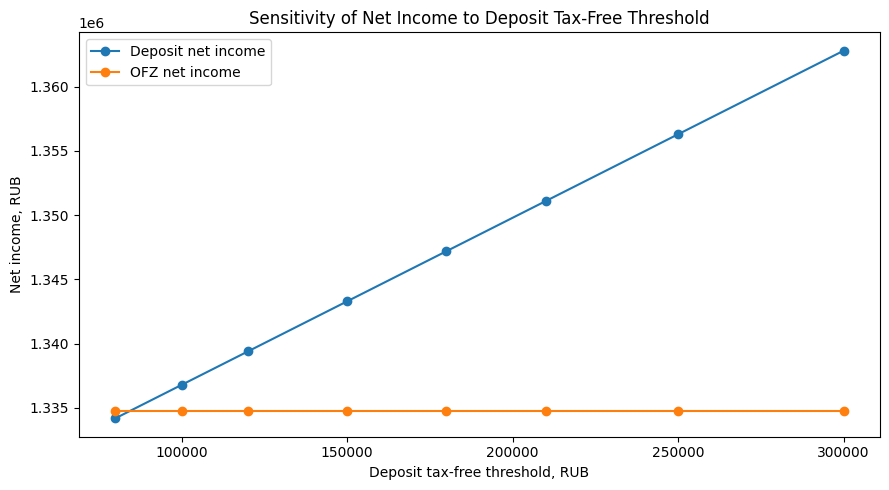

In [33]:
plt.figure(figsize=(9, 5))
plt.plot(
    sensitivity["deposit_tax_free_threshold"],
    sensitivity["deposit_net_income_rub"],
    marker="o",
    label="Deposit net income"
)
plt.plot(
    sensitivity["deposit_tax_free_threshold"],
    sensitivity["ofz_net_income_rub"],
    marker="o",
    label="OFZ net income"
)
plt.title("Sensitivity of Net Income to Deposit Tax-Free Threshold")
plt.xlabel("Deposit tax-free threshold, RUB")
plt.ylabel("Net income, RUB")
plt.legend()
plt.tight_layout()
plt.show()